In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from utils.animal_dataset import AnimalDataset
from model import ModelCnn
from utils.early_stopping import EarlyStopping
from utils.testing import Testing, check_errors
from utils.training import Trainer, plot_history

/home/mamp/Documents/semestre8/redes-neuronales-vision-computacion/proyecto/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Transformations for the dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Transformaciones fijas para validación y prueba
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Total de imágenes cargadas: 1052
Formato del tensor: torch.Size([3, 224, 224])
Clase detectada: 3


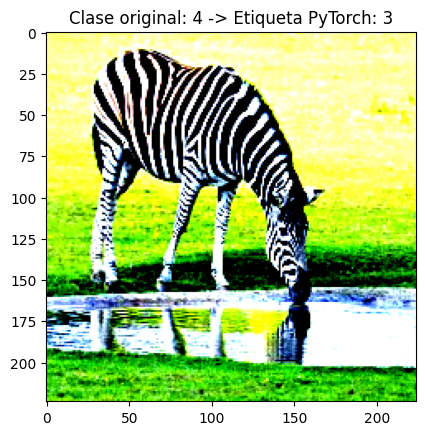

In [3]:
# Loading data

train_data = AnimalDataset(root_dir="../../data/africa-wildlife/images/train", transform=train_transform)

print(f"Total de imágenes cargadas: {len(train_data)}")

# Take a sample
img, label = train_data[0]
print(f"Formato del tensor: {img.shape}") # Should be [3, 224, 224]
print(f"Clase detectada: {label}")

plt.imshow(img.permute(1, 2, 0))
plt.title(f"Clase original: {label + 1} -> Etiqueta PyTorch: {label}")
plt.show()

In [4]:
val_data = AnimalDataset(root_dir="../../data/africa-wildlife/images/val", transform=val_test_transforms)
test_data = AnimalDataset(root_dir="../../data/africa-wildlife/images/test", transform=val_test_transforms)


In [5]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False, num_workers=2)

In [6]:
# Model Hyperparameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

model = ModelCnn(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

Usando: cuda


In [7]:
# Training model

model_trainer = Trainer(model, device, criterion, optimizer, EarlyStopping(patience=5))
history = model_trainer.fit(train_loader, val_loader, 20)

Epoch 1/20 -> Train Loss: 1.1576 | Acc: 49.62% | Val Loss: 1.1938 | Val Acc: 56.89%


Epoch 2/20 -> Train Loss: 0.8434 | Acc: 63.50% | Val Loss: 1.0136 | Val Acc: 60.89%


Epoch 3/20 -> Train Loss: 0.7995 | Acc: 66.25% | Val Loss: 1.0051 | Val Acc: 59.11%


Epoch 4/20 -> Train Loss: 0.7118 | Acc: 69.87% | Val Loss: 1.1554 | Val Acc: 61.33%


Epoch 5/20 -> Train Loss: 0.6699 | Acc: 72.43% | Val Loss: 0.9441 | Val Acc: 65.78%


Epoch 6/20 -> Train Loss: 0.6061 | Acc: 75.00% | Val Loss: 0.9752 | Val Acc: 64.44%


Epoch 7/20 -> Train Loss: 0.5444 | Acc: 80.42% | Val Loss: 1.0203 | Val Acc: 65.33%


Epoch 8/20 -> Train Loss: 0.4766 | Acc: 81.37% | Val Loss: 1.1015 | Val Acc: 67.56%


Epoch 9/20 -> Train Loss: 0.4165 | Acc: 83.84% | Val Loss: 1.3146 | Val Acc: 65.78%


Epoch 10/20 -> Train Loss: 0.3680 | Acc: 86.22% | Val Loss: 1.2834 | Val Acc: 62.22%
Early stopping activado. Terminando...


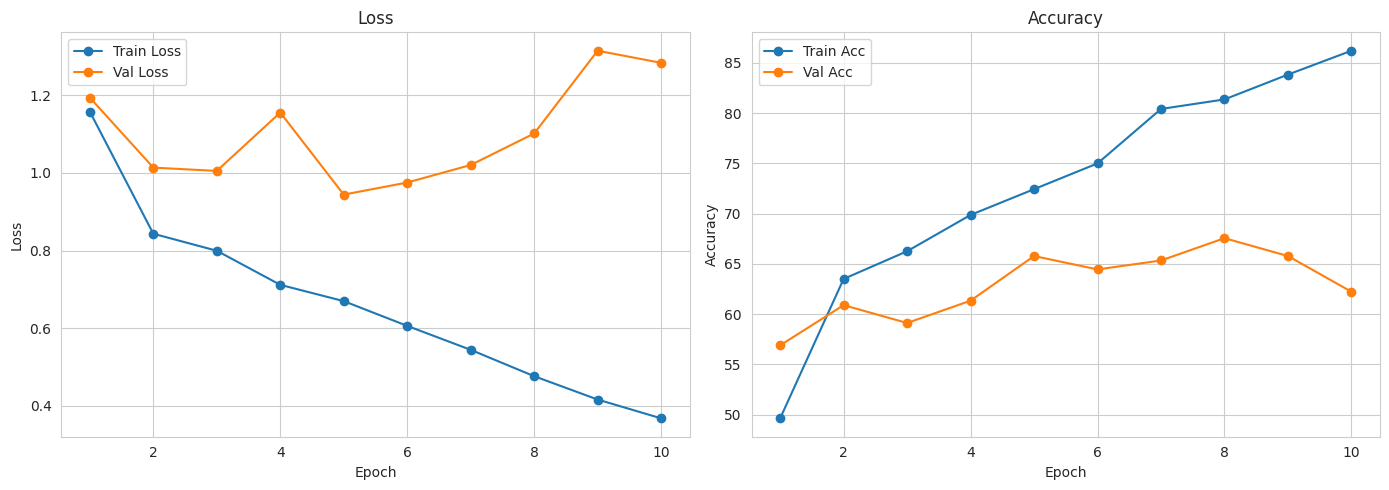

In [10]:
plot_history(history)

Test Accuracy Global: 69.16%
Accuracy de buffalo: 79.59%
Accuracy de elephant: 42.11%
Accuracy de rhino: 72.73%
Accuracy de zebra: 81.82%


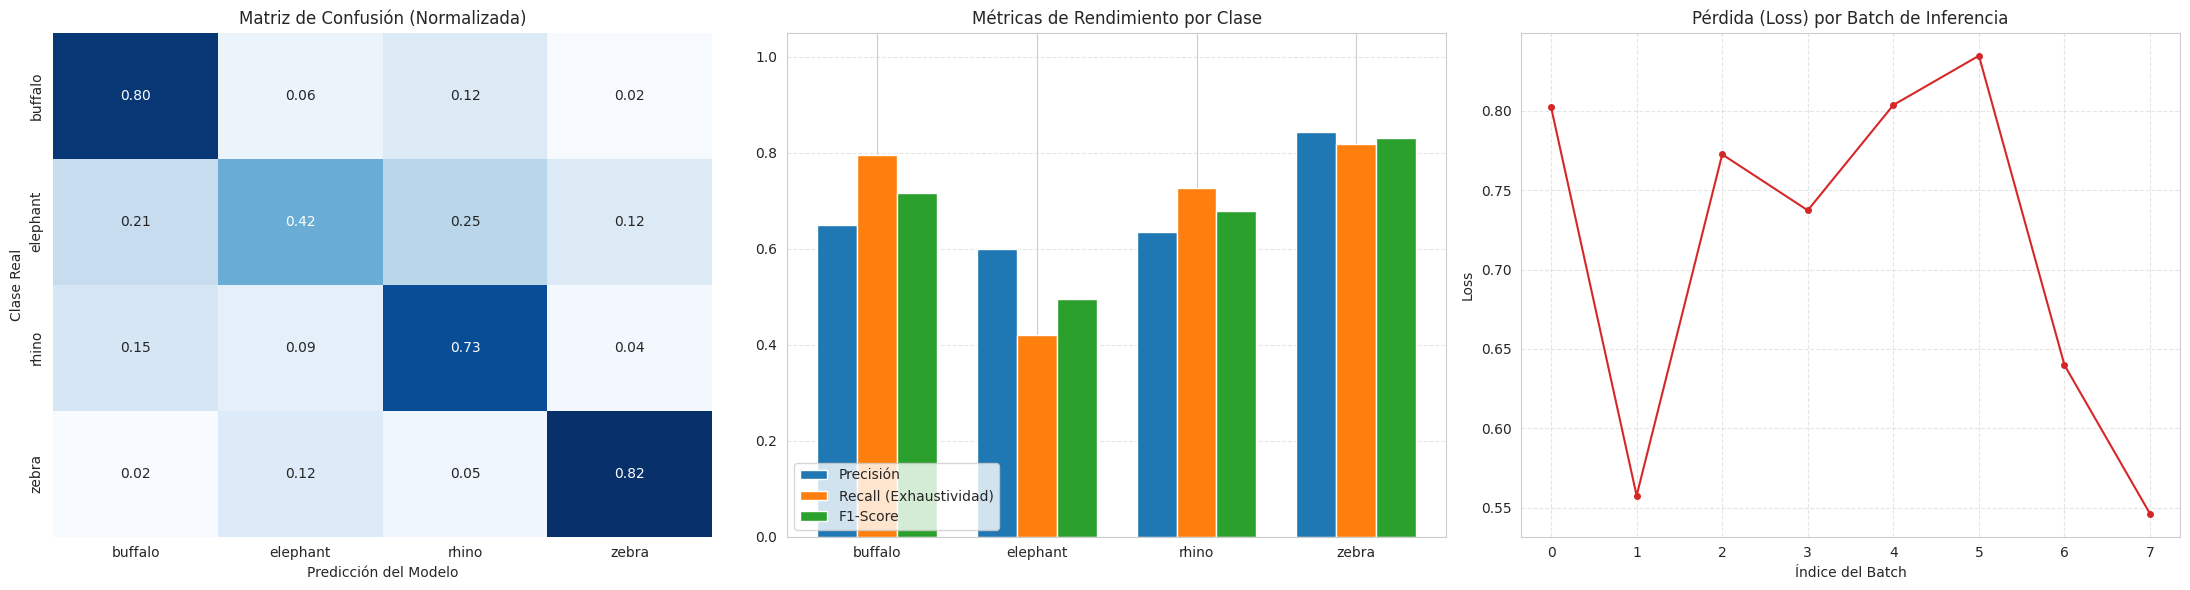


 INFORME DE MÉTRICAS (Classification Report)
              precision    recall  f1-score   support

     buffalo       0.65      0.80      0.72        49
    elephant       0.60      0.42      0.49        57
       rhino       0.63      0.73      0.68        55
       zebra       0.84      0.82      0.83        66

    accuracy                           0.69       227
   macro avg       0.68      0.69      0.68       227
weighted avg       0.69      0.69      0.68       227



In [11]:
# Testing model

model_tester = Testing(model, "best_model.pth", device, criterion)
test_loss = model_tester.test(test_loader)


# Probando MobileNetV2

In [7]:
from torchvision import models

# 1. Cargamos el modelo con pesos de ImageNet (el estándar actual en PyTorch)
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# 2. "Congelamos" las capas base (no queremos que olviden lo que ya saben de ImageNet)
for param in model.features.parameters():
    param.requires_grad = False

# 3. Cambiamos el clasificador final
# MobileNetV2 tiene 1280 neuronas en su última capa antes de la salida
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 4) # Tus 4 clases: búfalo, elefante, rino, cebra
)

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

model = model.to(device)

In [8]:
model_trainer = Trainer(model, device, criterion, optimizer, EarlyStopping(patience=5))
history = model_trainer.fit(train_loader, val_loader, 20)

Epoch 1/20 -> Train Loss: 0.5783 | Acc: 81.08% | Val Loss: 0.2511 | Val Acc: 89.78%


Epoch 2/20 -> Train Loss: 0.1705 | Acc: 94.87% | Val Loss: 0.2182 | Val Acc: 91.56%


Epoch 3/20 -> Train Loss: 0.1375 | Acc: 95.25% | Val Loss: 0.2340 | Val Acc: 90.67%


Epoch 4/20 -> Train Loss: 0.1514 | Acc: 94.58% | Val Loss: 0.4645 | Val Acc: 87.11%


Epoch 5/20 -> Train Loss: 0.1190 | Acc: 95.82% | Val Loss: 0.1880 | Val Acc: 94.22%


Epoch 6/20 -> Train Loss: 0.0970 | Acc: 96.77% | Val Loss: 0.1920 | Val Acc: 92.44%


Epoch 7/20 -> Train Loss: 0.0926 | Acc: 96.39% | Val Loss: 0.2164 | Val Acc: 92.00%


Epoch 8/20 -> Train Loss: 0.0859 | Acc: 96.96% | Val Loss: 0.2240 | Val Acc: 90.67%


Epoch 9/20 -> Train Loss: 0.0681 | Acc: 97.81% | Val Loss: 0.2169 | Val Acc: 91.56%


Epoch 10/20 -> Train Loss: 0.0787 | Acc: 97.34% | Val Loss: 0.2498 | Val Acc: 91.11%
Early stopping activado. Terminando...


In [ ]:
plot_history(history)

Test Accuracy Global: 95.15%
Accuracy de buffalo: 95.92%
Accuracy de elephant: 89.47%
Accuracy de rhino: 96.36%
Accuracy de zebra: 98.48%


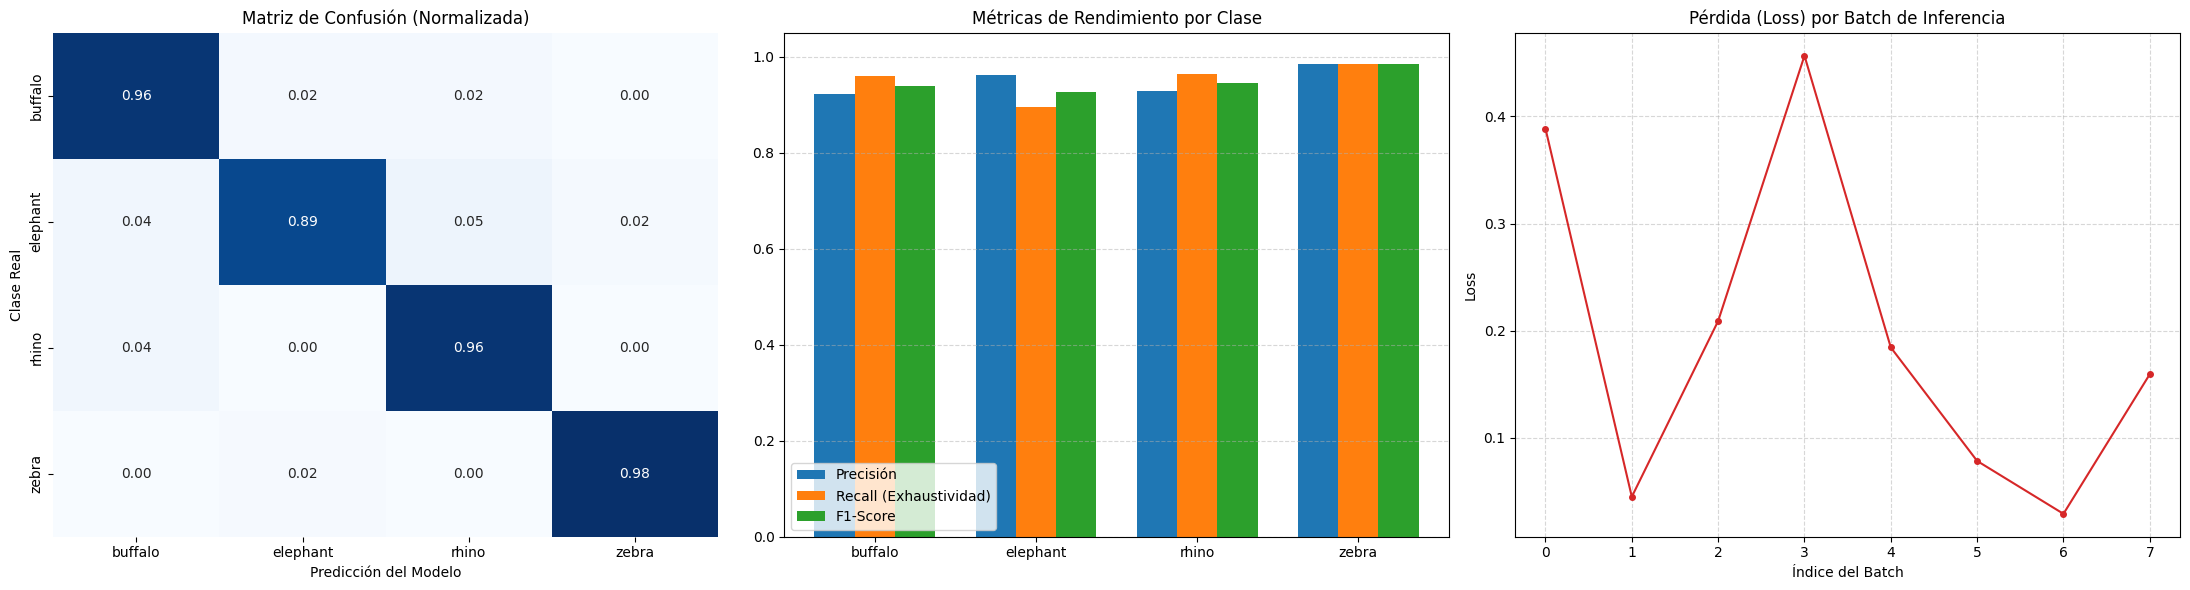


 INFORME DE MÉTRICAS (Classification Report)
              precision    recall  f1-score   support

     buffalo       0.92      0.96      0.94        49
    elephant       0.96      0.89      0.93        57
       rhino       0.93      0.96      0.95        55
       zebra       0.98      0.98      0.98        66

    accuracy                           0.95       227
   macro avg       0.95      0.95      0.95       227
weighted avg       0.95      0.95      0.95       227



In [9]:
model_tester = Testing(model, "best_model.pth", device, criterion)
test_loss = model_tester.test(test_loader)

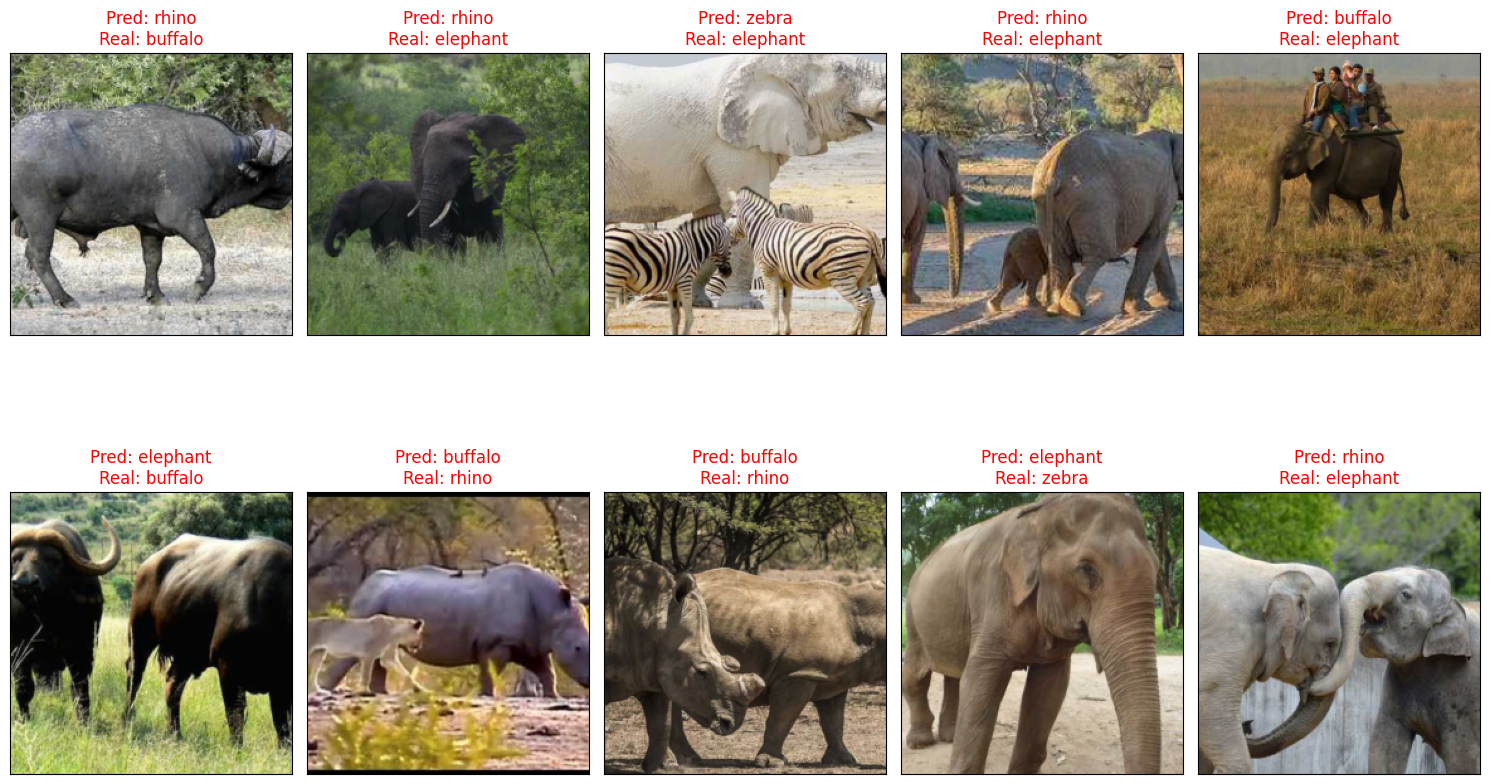

In [11]:
check_errors(model, device, test_loader, ['buffalo', 'elephant', 'rhino', 'zebra'])